<div style="background: linear-gradient(135deg, #059669 0%, #0d9488 100%); padding: 24px; border-radius: 12px; color: white;">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Hotel Booking Project</h1>
    <div style="background: rgba(255, 255, 255, 0.15); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Question:</strong> Is our hotel revenue growing yearly?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs2.pkl')
df = all_dfs['df']
clean_df = all_dfs['clean_df']

In [11]:
# Group by the boolean cancellation column and aggregate revenue
revenue_summary = clean_df.groupby('is_cancelled')['total_booking_revenue'].agg(
    total_revenue='sum',
    average_booking_value='mean',
    booking_count='count'
).reset_index()

# Map boolean values to readable labels
revenue_summary['is_cancelled'] = revenue_summary['is_cancelled'].map({False: 'Completed Stays', True: 'Cancelled Stays'})
print(revenue_summary)

      is_cancelled  total_revenue  average_booking_value  booking_count
0  Completed Stays     3290213.22             338.116660           9731
1  Cancelled Stays      908865.85             407.197961           2232


In [37]:
# Assuming a standard hotel capacity or calculating based on total unique room nights available
# First, let's group completed revenue by year (if your data spans multiple years)
# Extract year from arrival date if not already done:
clean_df['arrival_year'] = pd.to_datetime(clean_df['arrival_date'], errors='coerce').dt.year

# Calculate RevPAR or annual gross revenue metrics
annual_revenue = clean_df[clean_df['is_cancelled'] == False].groupby('arrival_year').agg(
    total_realized_revenue=('total_booking_revenue', 'sum'),
    completed_stays=('total_booking_revenue', 'count'),
    average_adr=('adr', 'mean')
).reset_index()

print(annual_revenue)

   arrival_year  total_realized_revenue  completed_stays  average_adr
0          2018              3290213.22             9731    89.599342


In [38]:
# Compare total potential revenue of bookings vs. what was actually realized
potential_vs_realized = clean_df.groupby('is_cancelled')['total_booking_revenue'].sum().reset_index()
potential_vs_realized['is_cancelled'] = potential_vs_realized['is_cancelled'].map({False: 'Realized Revenue', True: 'Lost to Cancellation'})
print(potential_vs_realized)

           is_cancelled  total_booking_revenue
0      Realized Revenue             3290213.22
1  Lost to Cancellation              908865.85


In [39]:
# Group by deposit type and cancellation status to see revenue and volume
deposit_analysis = clean_df.groupby(['deposit_type', 'is_cancelled']).agg(
    booking_count=('adr', 'count'),
    total_revenue=('total_booking_revenue', 'sum')
).reset_index()

# Map boolean cancellation to readable labels
deposit_analysis['is_cancelled'] = deposit_analysis['is_cancelled'].map({False: 'Completed', True: 'Cancelled'})

print(deposit_analysis.to_string(index=False))

deposit_type is_cancelled  booking_count  total_revenue
  No Deposit    Completed           9721     3287862.47
  No Deposit    Cancelled           2129      885802.55
  Non Refund    Completed              6        1519.00
  Non Refund    Cancelled            103       23063.30
  Refundable    Completed              4         831.75


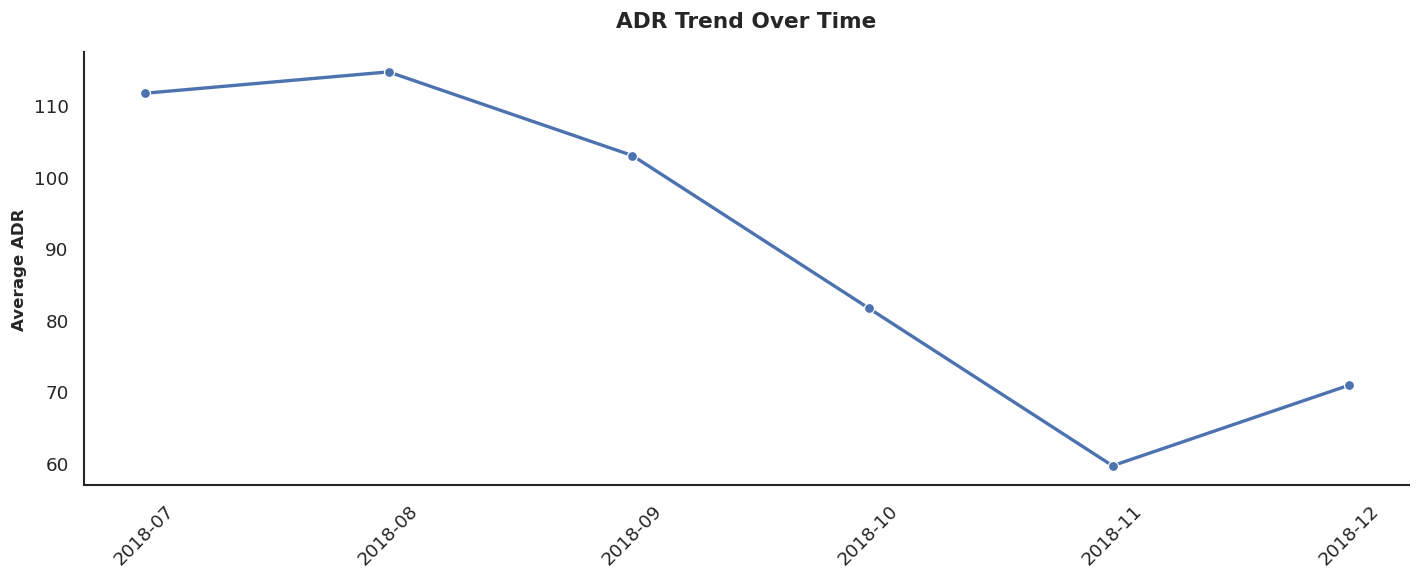

In [40]:
#average ADR by month

monthly_trend = clean_df.groupby(clean_df['arrival_date'].dt.to_period('M'))['adr'].mean().reset_index()
monthly_trend['arrival_date'] = monthly_trend['arrival_date'].dt.to_timestamp()

#line chart
plt.figure(figsize=(12, 5), dpi=120)
sns.lineplot(data=monthly_trend, x='arrival_date', y='adr', marker='o', linewidth=2)

sns.despine(top=True, right=True)
plt.title("ADR Trend Over Time", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("", fontsize=10, fontweight="bold")
plt.ylabel("Average ADR", fontsize=10, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

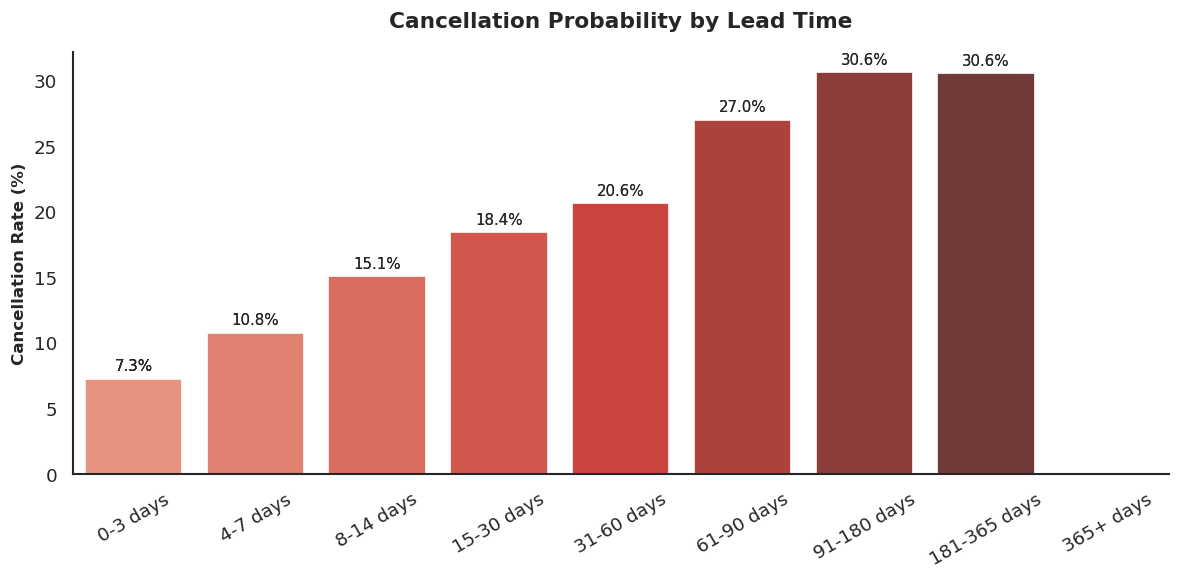

In [41]:
#cancellation % by lead_time



bins = [-1, 3, 7, 14, 30, 60, 90, 180, 365, float('inf')]
labels = ['0-3 days', '4-7 days', '8-14 days', '15-30 days', 
    '31-60 days', '61-90 days', '91-180 days', '181-365 days', '365+ days']
clean_df['lead_time_bin'] = pd.cut(clean_df["lead_time"], bins=bins, labels=labels)


cancel_trend = clean_df.groupby('lead_time_bin', observed=False)["is_cancelled"].mean().reset_index()
cancel_trend['cancellation_rate'] = cancel_trend["is_cancelled"] * 100




plt.figure(figsize=(10, 5), dpi=120)
sns.barplot(
    data=cancel_trend, 
    x='lead_time_bin', 
    y='cancellation_rate', 
    hue='lead_time_bin', 
    palette='Reds_d', 
    legend=False
)


ax = sns.barplot(
    data=cancel_trend, 
    x='lead_time_bin', 
    y='cancellation_rate', 
    hue='lead_time_bin', 
    palette='Reds_d', 
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=9)

sns.despine(top=True, right=True)
plt.title("Cancellation Probability by Lead Time", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("", fontsize=10, fontweight="bold")
plt.ylabel("Cancellation Rate (%)", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

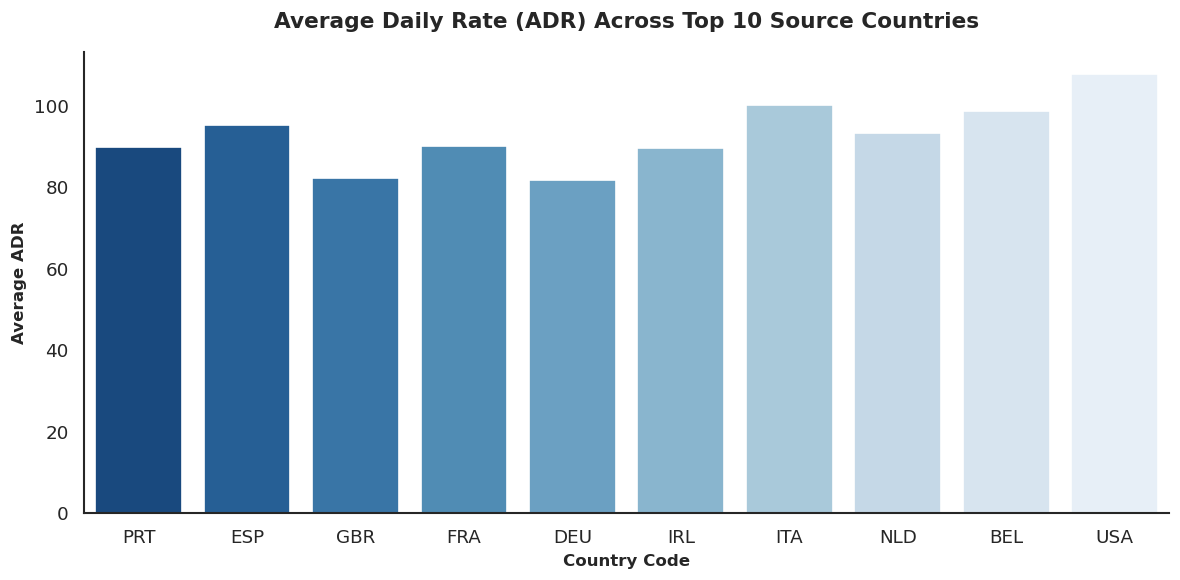

In [43]:
# top 10 countries ADR


top_countries = clean_df['country'].value_counts().head(10).index
geo_df = clean_df[clean_df['country'].isin(top_countries)]

geo_summary = geo_df.groupby('country').agg(
    avg_adr=('adr', 'mean'),
    total_bookings=('adr', 'count')
).reset_index().sort_values(by='total_bookings', ascending=False)

#plotting
plt.figure(figsize=(10, 5), dpi=120)
sns.barplot(
    data=geo_summary, 
    x='country', 
    y='avg_adr', 
    hue='country', 
    palette='Blues_r', 
    legend=False
)

sns.despine(top=True, right=True)
plt.title("Average Daily Rate (ADR) Across Top 10 Source Countries", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Country Code", fontsize=10, fontweight="bold")
plt.ylabel("Average ADR", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()